# Basic Text Classification w/ Keras

https://www.tensorflow.org/tutorials/keras/text_classification

In [1]:
import matplotlib.pyplot as plt
import os
import re
import shutil
import string
import tensorflow as tf

from pathlib import Path
from tensorflow.keras import layers, losses, preprocessing
from tensorflow.keras.layers.experimental.preprocessing import TextVectorization

# Binary Classification (Dataset: IMDB Reviews)

## Dataset Fetch

In [2]:
dataset_url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

In [3]:
datasets_dir = Path(os.path.abspath('')).parent.joinpath('datasets')
datasets_dir.mkdir(parents=True, exist_ok=True)

In [4]:
dataset = tf.keras.utils.get_file(fname="aclImdb_v1.tar.gz", 
                                  origin=dataset_url,
                                  extract=True, 
                                  cache_dir=datasets_dir,
                                  cache_subdir='')

84125825/84125825 [==============================] - 111s 1us/step


In [5]:
imdb_dataset_dir = datasets_dir.joinpath('aclimdb')

In [6]:
imdb_train_dataset = imdb_dataset_dir.joinpath('train')
imdb_test_dataset = imdb_dataset_dir.joinpath('test')

In [7]:
os.listdir(imdb_train_dataset)

['urls_unsup.txt',
 'neg',
 'urls_pos.txt',
 'unsup',
 'urls_neg.txt',
 'pos',
 'unsupBow.feat',
 'labeledBow.feat']

In [8]:
"""Drops the 'unsup' dataset since we're doing a binary classification (pos/neg)"""
imdb_train_dataset_unsup = imdb_train_dataset.joinpath('unsup')
shutil.rmtree(imdb_train_dataset_unsup, ignore_errors=True)

## Dataset Load

In [9]:
"""
Loads the Dataset in Batches/Lists of 32 entries each,
meaning that each iteration over the dataset will return 32 reviews
"""
batch_size = 32
seed = 42

### Loading Training Dataset

In [10]:
raw_train_ds = tf.keras.preprocessing.text_dataset_from_directory(
    imdb_train_dataset,
    batch_size=batch_size,
    seed=seed,
    validation_split=0.2,
    subset='training'
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.


2024-01-27 02:49:43.035724: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2024-01-27 02:49:43.035757: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2024-01-27 02:49:43.035766: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2024-01-27 02:49:43.035826: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-01-27 02:49:43.035852: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### Analysis of the Training Dataset

In [11]:
"""Available Classes"""
raw_train_ds.class_names

['neg', 'pos']

In [12]:
for text_batch, label_batch in raw_train_ds.take(1):
    for i in range(3):
        tokenized_label = label_batch.numpy()[i]
        corpus=text_batch.numpy()[i]
        class_name = raw_train_ds.class_names[tokenized_label]
        print(f"Label: {tokenized_label} ({class_name})")
        print(f"Review: {corpus}")
        print()

Label: 0 (neg)
Review: b'"Pandemonium" is a horror movie spoof that comes off more stupid than funny. Believe me when I tell you, I love comedies. Especially comedy spoofs. "Airplane", "The Naked Gun" trilogy, "Blazing Saddles", "High Anxiety", and "Spaceballs" are some of my favorite comedies that spoof a particular genre. "Pandemonium" is not up there with those films. Most of the scenes in this movie had me sitting there in stunned silence because the movie wasn\'t all that funny. There are a few laughs in the film, but when you watch a comedy, you expect to laugh a lot more than a few times and that\'s all this film has going for it. Geez, "Scream" had more laughs than this film and that was more of a horror film. How bizarre is that?<br /><br />*1/2 (out of four)'

Label: 0 (neg)
Review: b"David Mamet is a very interesting and a very un-equal director. His first movie 'House of Games' was the one I liked best, and it set a series of films with characters whose perspective of life 

### Loading Validation Dataset

In [13]:
raw_validation_ds = tf.keras.preprocessing.text_dataset_from_directory(
    imdb_train_dataset,
    batch_size=batch_size,
    seed=seed,
    validation_split=0.2,
    subset='validation'
)

Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


### Loading Test Dataset

In [14]:
raw_test_ds = tf.keras.preprocessing.text_dataset_from_directory(
    imdb_test_dataset,
    batch_size=batch_size
)

Found 25000 files belonging to 2 classes.


## Dataset Preprocessing

### Standarization Function

In [15]:
def standardize_fn(input_data):
    lowercase_corpus = tf.strings.lower(input_data)
    stripped_html = tf.strings.regex_replace(input=lowercase_corpus, 
                                             pattern='<br />', 
                                             rewrite='')

    return tf.strings.regex_replace(input=stripped_html, 
                                    pattern='[%s]' % re.escape(string.punctuation), 
                                    rewrite='')

### Tokenization & Vectorization

In [16]:
"""Define the size of the vocabulary (the max number of words to be tokenized)"""
max_features = 100000
sequence_length = 250

vectorize_layer = TextVectorization(
    standardize=standardize_fn,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length
)

def vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return vectorize_layer(text), label

### Testing & Visualization

In [17]:
train_text = raw_train_ds.map(lambda text, class_label: text)

In [18]:
vectorize_layer.adapt(train_text)

2024-01-27 02:49:43.903281: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


In [19]:
# retrieve a batch (of 32 reviews and labels) from the dataset
text_batch, label_batch = next(iter(raw_train_ds))
review, label = text_batch[0], label_batch[0]

In [20]:
print("Pre-processing Review: ", review)

Pre-processing Review:  tf.Tensor(b'Great movie - especially the music - Etta James - "At Last". This speaks volumes when you have finally found that special someone.', shape=(), dtype=string)


In [21]:
print("Post-processing Review: ", standardize_fn(review))

Post-processing Review:  tf.Tensor(b'great movie  especially the music  etta james  at last this speaks volumes when you have finally found that special someone', shape=(), dtype=string)


In [22]:
print("Label: ", raw_train_ds.class_names[label])

Label:  neg


In [23]:
print("Vectorized review: ", vectorize_text(review, label))

Vectorized review:  (<tf.Tensor: shape=(1, 250), dtype=int64, numpy=
array([[   85,    17,   257,     2,   222,     1,   574,    30,   227,
           10,  2401, 10458,    52,    23,    25,   426,   248,    12,
          306,   279,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
        

In [24]:
print("{token} ==> {word}".format(token=11, word=vectorize_layer.get_vocabulary()[11]))
print("{token} ==> {word}".format(token=57, word=vectorize_layer.get_vocabulary()[57]))
print("{token} ==> {word}".format(token=1270, word=vectorize_layer.get_vocabulary()[1270]))

print("Vocabulary Size: {size}".format(size=len(vectorize_layer.get_vocabulary())))

11 ==> i
57 ==> would
1270 ==> silent
Vocabulary Size: 100000


### Applying Vectorization on Training/Validation/Test Datasets

In [25]:
train_ds = raw_train_ds.map(vectorize_text)
validation_ds = raw_validation_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

### Caching Datasets to RAM

In [26]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds.cache().prefetch(buffer_size=AUTOTUNE)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 250), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

## Model Training

### Model Parametrization

In [27]:
embedding_dim = 16

In [28]:
model = tf.keras.Sequential([
    layers.Embedding(max_features+1, embedding_dim),
    layers.Dropout(0.2),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.2),
    layers.Dense(1)
])

In [29]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 16)          1600016   
                                                                 
 dropout (Dropout)           (None, None, 16)          0         
                                                                 
 global_average_pooling1d (  (None, 16)                0         
 GlobalAveragePooling1D)                                         
                                                                 
 dropout_1 (Dropout)         (None, 16)                0         
                                                                 
 dense (Dense)               (None, 1)                 17        
                                                                 
Total params: 1600033 (6.10 MB)
Trainable params: 1600033 (6.10 MB)
Non-trainable params: 0 (0.00 Byte)
__________________

In [30]:
model.compile(
    loss=losses.BinaryCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=tf.metrics.BinaryAccuracy(threshold=0.0)
)

### Model Training

In [31]:
epochs = 10

In [32]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs
)

Epoch 1/10
625/625 [==============================] - 17s 23ms/step - loss: 0.6642 - binary_accuracy: 0.7025 - val_loss: 0.6152 - val_binary_accuracy: 0.7842
Epoch 2/10
625/625 [==============================] - 12s 20ms/step - loss: 0.5437 - binary_accuracy: 0.8101 - val_loss: 0.4971 - val_binary_accuracy: 0.8266
Epoch 3/10
625/625 [==============================] - 11s 18ms/step - loss: 0.4341 - binary_accuracy: 0.8533 - val_loss: 0.4198 - val_binary_accuracy: 0.8494
Epoch 4/10
625/625 [==============================] - 11s 18ms/step - loss: 0.3610 - binary_accuracy: 0.8768 - val_loss: 0.3716 - val_binary_accuracy: 0.8654
Epoch 5/10
625/625 [==============================] - 11s 17ms/step - loss: 0.3104 - binary_accuracy: 0.8952 - val_loss: 0.3414 - val_binary_accuracy: 0.8712
Epoch 6/10
625/625 [==============================] - 11s 18ms/step - loss: 0.2731 - binary_accuracy: 0.9104 - val_loss: 0.3207 - val_binary_accuracy: 0.8768
Epoch 7/10
625/625 [==============================] 

### Model Evaluation

In [33]:
loss, accuracy = model.evaluate(test_ds)

782/782 [==============================] - 4s 5ms/step - loss: 0.3172 - binary_accuracy: 0.8694


In [34]:
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

Loss: 0.3172268271446228
Accuracy: 0.8694000244140625


In [35]:
history_dict = history.history
history_dict.keys()

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])

In [36]:
bin_acc = history_dict['binary_accuracy']
validation_acc = history_dict['val_binary_accuracy']

In [37]:
loss = history_dict['loss']
validation_loss = history_dict['val_loss']

In [38]:
epochs = range(1, len(bin_acc) + 1)

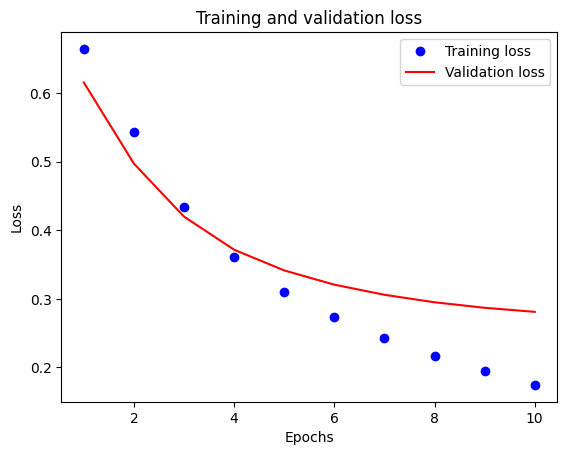

In [39]:
# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, validation_loss, 'red', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

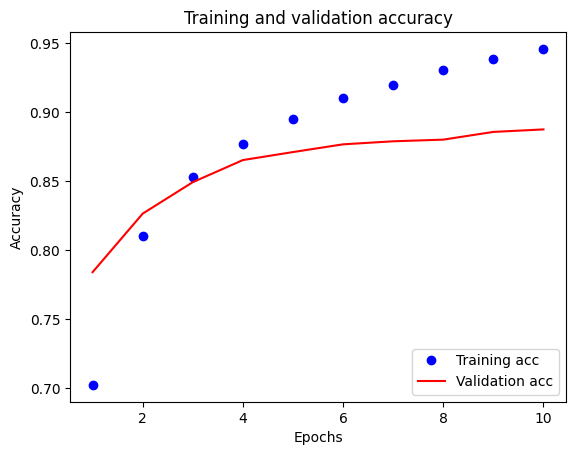

In [40]:
plt.plot(epochs, bin_acc, 'bo', label='Training acc')
plt.plot(epochs, validation_acc, 'red', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()

### Model Export

In [41]:
export_model = tf.keras.Sequential([
    vectorize_layer,
    model,
    layers.Activation('sigmoid')
])

In [42]:
export_model.compile(loss=losses.BinaryCrossentropy(from_logits=False),
                     optimizer='adam',
                     metrics=['accuracy'])

In [43]:
loss, accuracy = export_model.evaluate(raw_test_ds)

782/782 [==============================] - 5s 6ms/step - loss: 0.3172 - accuracy: 0.8694


In [44]:
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

Loss: 0.31722670793533325
Accuracy: 0.8694000244140625


## Model Inference

In [45]:
examples = [
  "The movie was great!",
  "The movie was okay.",
  "The movie was terrible..."
]

export_model.predict(examples)

1/1 [==============================] - 0s 84ms/step


array([[0.6384243 ],
       [0.45585543],
       [0.37682113]], dtype=float32)